In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import pool
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data, DataLoader
import torch_geometric.transforms as T

import combined_models

import os
import gzip
from scipy import io
import pickle

In [2]:
from torch_geometric.explain import Explainer, GNNExplainer, AttentionExplainer, PGExplainer
from torch_geometric.utils import remove_self_loops, to_undirected
from tqdm import tqdm

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
device

device(type='cuda')

# construct torch-geometric data

In [5]:
from joblib import Parallel, delayed

In [6]:
def dataObject(graph, exp_df, ssa):
    nodes = np.unique(graph)
    node_features = exp_df.loc[nodes]
    edge_index = [(node_features.index.get_loc(node1), node_features.index.get_loc(node2)) for node1, node2 in graph]
    data = Data(x=torch.tensor(node_features.values, dtype=torch.float32), edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(), label=torch.tensor([ssa]))
    return data

## xenium 83a

In [7]:
graphs = pd.read_pickle(r"..\..\..\nanostring_xenium_comp\results\graph_classification_v5\xenium\sub_graphs_83a.pkl")
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r"..\results\dann\common_genes\83_a_corrected.csv", index_col=0)

In [8]:
data = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:   23.4s
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:   23.6s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:   23.7s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:   23.8s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:   23.9s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:   23.9s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:   24.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:   24.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:   24.0s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:   24.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:   24.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:   24.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:   24.2s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:   24.3s
[Parallel(n_jobs=-3)]: Done  15 tasks      | elapsed:  

In [9]:
with open(r'..\results\dann\common_genes\torch_geometric_data\sub_graphs_83a.pkl', 'wb') as f:
    pickle.dump(data, f)

## xenium 83b

In [10]:
graphs = pd.read_pickle(r"..\..\..\nanostring_xenium_comp\results\graph_classification_v5\xenium\sub_graphs_83b.pkl")
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r"..\results\dann\common_genes\83_b_corrected.csv", index_col=0)

In [ ]:
data = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.1986069679260254s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]:

In [ ]:
with open(r'..\results\dann\common_genes\torch_geometric_data\sub_graphs_83b.pkl', 'wb') as f:
    pickle.dump(data, f)

## xenium 84a

In [ ]:
graphs = pd.read_pickle(r"..\..\..\nanostring_xenium_comp\results\graph_classification_v5\xenium\sub_graphs_84a.pkl")
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r"..\results\dann\common_genes\84_a_corrected.csv", index_col=0)

In [ ]:
data = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.190995454788208s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: 

In [ ]:
with open(r'..\results\dann\common_genes\torch_geometric_data\sub_graphs_84a.pkl', 'wb') as f:
    pickle.dump(data, f)

## xenium 84b

In [ ]:
graphs = pd.read_pickle(r"..\..\..\nanostring_xenium_comp\results\graph_classification_v5\xenium\sub_graphs_84b.pkl")
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r"..\results\dann\common_genes\84_b_corrected.csv", index_col=0)

In [ ]:
data = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.1883680820465088s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-3)]:

In [ ]:
with open(r'..\results\dann\common_genes\torch_geometric_data\sub_graphs_84b.pkl', 'wb') as f:
    pickle.dump(data, f)

## xenium 174c

In [ ]:
graphs = pd.read_pickle(r"..\..\..\nanostring_xenium_comp\results\graph_classification_v5\xenium\sub_graphs_174c.pkl")
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r"..\results\dann\common_genes\174_c_corrected.csv", index_col=0)

In [ ]:
data = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.12130165100097656s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]

In [ ]:
with open(r'..\results\dann\common_genes\torch_geometric_data\sub_graphs_174c.pkl', 'wb') as f:
    pickle.dump(data, f)

## xenium 174d

In [ ]:
graphs = pd.read_pickle(r"..\..\..\nanostring_xenium_comp\results\graph_classification_v5\xenium\sub_graphs_174d.pkl")
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r"..\results\dann\common_genes\174_d_corrected.csv", index_col=0)

In [ ]:
data = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.11266112327575684s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]

In [ ]:
with open(r'..\results\dann\common_genes\torch_geometric_data\sub_graphs_174d.pkl', 'wb') as f:
    pickle.dump(data, f)

## xenium 7202c

In [ ]:
graphs = pd.read_pickle(r"..\..\..\nanostring_xenium_comp\results\graph_classification_v5\xenium\sub_graphs_7202c.pkl")
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r"..\results\dann\common_genes\7202_c_corrected.csv", index_col=0)

In [ ]:
data = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.10849118232727051s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]

In [ ]:
with open(r'..\results\dann\common_genes\torch_geometric_data\sub_graphs_7202c.pkl', 'wb') as f:
    pickle.dump(data, f)

## xenium 7202d

In [ ]:
graphs = pd.read_pickle(r"..\..\..\nanostring_xenium_comp\results\graph_classification_v5\xenium\sub_graphs_7202d.pkl")
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r"..\results\dann\common_genes\7202_d_corrected.csv", index_col=0)

In [ ]:
data = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 out of   1 | elapsed:    2.3s finished
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-3)]: Done  14 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-3)]: Done  15 tasks      | e

In [ ]:
with open(r'..\results\dann\common_genes\torch_geometric_data\sub_graphs_7202d.pkl', 'wb') as f:
    pickle.dump(data, f)

## merfish r1 7289

In [ ]:
graphs = pd.read_pickle(r"..\results\stromal_neighborhoods\sub_graphs_R1_7289.pkl")
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r"..\results\dann\common_genes\region_R1_corrected.csv", index_col=0)

In [ ]:
data = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.128798246383667s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-3)]: 

In [ ]:
with open(r'..\results\dann\common_genes\torch_geometric_data\sub_graphs_R1-7289.pkl', 'wb') as f:
    pickle.dump(data, f)

## merfish r2 7295

In [ ]:
graphs = pd.read_pickle(r"..\results\stromal_neighborhoods\sub_graphs_R2_7295.pkl")
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r"..\results\dann\common_genes\region_R2_corrected.csv", index_col=0)

In [ ]:
data = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.07984781265258789s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]

In [ ]:
with open(r'..\results\dann\common_genes\torch_geometric_data\sub_graphs_R2-7295.pkl', 'wb') as f:
    pickle.dump(data, f)

## merfish r3 7320

In [ ]:
graphs = pd.read_pickle(r"..\results\stromal_neighborhoods\sub_graphs_R3_7320.pkl")
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r"..\results\dann\common_genes\region_R3_corrected.csv", index_col=0)

In [ ]:
data = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 1) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.07626914978027344s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]

In [ ]:
with open(r'..\results\dann\common_genes\torch_geometric_data\sub_graphs_R3-7320.pkl', 'wb') as f:
    pickle.dump(data, f)

## merfish r8 159

In [ ]:
graphs = pd.read_pickle(r"..\results\stromal_neighborhoods\sub_graphs_R8_159.pkl")
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r"..\results\dann\common_genes\region_R8_corrected.csv", index_col=0)

In [ ]:
data = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.0752878189086914s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]:

In [ ]:
with open(r'..\results\dann\common_genes\torch_geometric_data\sub_graphs_R8-159.pkl', 'wb') as f:
    pickle.dump(data, f)

## merfish r9 163

In [ ]:
graphs = pd.read_pickle(r"..\results\stromal_neighborhoods\sub_graphs_R9_163.pkl")
graphs = [item for item in graphs if len(item) > 0]
exp_df = pd.read_csv(r"..\results\dann\common_genes\region_R9_corrected.csv", index_col=0)

In [ ]:
data = Parallel(n_jobs=-3, verbose=1000)(delayed(dataObject)(graph, exp_df, 0) for graph in graphs)

[Parallel(n_jobs=-3)]: Using backend LokyBackend with 46 concurrent workers.
[Parallel(n_jobs=-3)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Batch computation too fast (0.08527302742004395s.) Setting batch_size=2.
[Parallel(n_jobs=-3)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-3)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-3)]

In [ ]:
with open(r'..\results\dann\common_genes\torch_geometric_data\sub_graphs_R9-163.pkl', 'wb') as f:
    pickle.dump(data, f)

# Load data

In [7]:
xenium_data_83a = pd.read_pickle(r"..\results\dann\common_genes\torch_geometric_data\sub_graphs_83a.pkl")
xenium_data_83b = pd.read_pickle(r"..\results\dann\common_genes\torch_geometric_data\sub_graphs_83b.pkl")
xenium_data_84a = pd.read_pickle(r"..\results\dann\common_genes\torch_geometric_data\sub_graphs_84a.pkl")
xenium_data_84b = pd.read_pickle(r"..\results\dann\common_genes\torch_geometric_data\sub_graphs_84b.pkl")
xenium_data_174c = pd.read_pickle(r"..\results\dann\common_genes\torch_geometric_data\sub_graphs_174c.pkl")
xenium_data_174d = pd.read_pickle(r"..\results\dann\common_genes\torch_geometric_data\sub_graphs_174d.pkl")
xenium_data_7202c = pd.read_pickle(r"..\results\dann\common_genes\torch_geometric_data\sub_graphs_7202c.pkl")
xenium_data_7202d = pd.read_pickle(r"..\results\dann\common_genes\torch_geometric_data\sub_graphs_7202d.pkl")

merfish_data_7289 = pd.read_pickle(r"..\results\dann\common_genes\torch_geometric_data\sub_graphs_R1-7289.pkl")
merfish_data_7295 = pd.read_pickle(r"..\results\dann\common_genes\torch_geometric_data\sub_graphs_R2-7295.pkl")
merfish_data_7320 = pd.read_pickle(r"..\results\dann\common_genes\torch_geometric_data\sub_graphs_R3-7320.pkl")
merfish_data_159 = pd.read_pickle(r"..\results\dann\common_genes\torch_geometric_data\sub_graphs_R8-159.pkl")
merfish_data_163 = pd.read_pickle(r"..\results\dann\common_genes\torch_geometric_data\sub_graphs_R9-163.pkl")

# spliting

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
xenium_data = xenium_data_83a+xenium_data_83b+xenium_data_84a+xenium_data_84b+\
       xenium_data_174c+xenium_data_174d+xenium_data_7202c+xenium_data_7202d
merfish_data = merfish_data_7289+merfish_data_7295+merfish_data_7320+merfish_data_159+merfish_data_163

for data in xenium_data:
    data.source_label = torch.LongTensor([0])
for data in merfish_data:
    data.source_label = torch.LongTensor([1])

labels = ['SSA+']*(len(xenium_data_83a)+len(xenium_data_83b)+len(xenium_data_84a)+len(xenium_data_84b))+\
         ['SSA-']*(len(xenium_data_174c)+len(xenium_data_174d)+len(xenium_data_7202c)+len(xenium_data_7202d))+\
         ['SSA+']*(len(merfish_data_7289)+len(merfish_data_7295)+len(merfish_data_7320))+\
         ['SSA-']*(len(merfish_data_159)+len(merfish_data_163))

In [10]:
data = xenium_data + merfish_data
train_data, test_data, train_label, test_label = train_test_split(data, labels, test_size=0.2, random_state=42)
train_data, val_data, train_label, val_label = train_test_split(data, labels, test_size=0.25, random_state=42)

In [11]:
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=True)

c:\Users\zfang38\AppData\Local\anaconda3\envs\torchEnv\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


# Training

In [12]:
from torch.nn import CrossEntropyLoss
from torch.optim import Adam, SGD
from sklearn.utils.class_weight import compute_class_weight

In [13]:
model = combined_models.GraphDANN([97, [75], 50, [3]], [300, [150, 50], 2])

In [14]:
model.to(device)

GraphDANN(
  (encoder): GATEncoder(
    (conv1): GATConv(97, 75, heads=3)
    (convs): ModuleList()
    (conv_out): GATConv(225, 50, heads=3)
  )
  (classifier): Classifier(
    (fc1): Linear(in_features=300, out_features=150, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=150, out_features=50, bias=True)
    )
    (out): Linear(in_features=50, out_features=2, bias=True)
  )
  (discriminator): Classifier(
    (fc1): Linear(in_features=300, out_features=150, bias=True)
    (fcs): ModuleList(
      (0): Linear(in_features=150, out_features=50, bias=True)
    )
    (out): Linear(in_features=50, out_features=2, bias=True)
  )
)

In [15]:
batch_labels = []
for data in train_data:
    batch_labels.append(data.source_label.numpy()[0])

In [16]:
label_weight = compute_class_weight(class_weight="balanced", classes=np.array(['SSA-', 'SSA+']), y=train_label)
label_weight = torch.tensor(label_weight, dtype=torch.float32)

batch_weight = compute_class_weight(class_weight="balanced", classes=np.array([0,1]),y=batch_labels)
batch_weight = torch.tensor(batch_weight, dtype=torch.float32)

In [17]:
optimizer = SGD(model.parameters(), lr=0.01)
label_criterion = CrossEntropyLoss(label_weight.to(device))
batch_criterion = CrossEntropyLoss(batch_weight.to(device))

In [18]:
def train(loader, lambd):
    model.train()
    total_loss = 0
    datasize = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        pred_out, batch_out = model(data.x, data.edge_index, data.batch, lambd)
        if data.label.shape[0] != pred_out.shape[0]:
            min_size = min(pred_out.shape[0], data.label.shape[0])
            pred_out = pred_out[:min_size]
            data.label = data.label[:min_size]
        if data.source_label.shape[0] != batch_out.shape[0]:
            min_size = min(batch_out.shape[0], data.source_label.shape[0])
            batch_out = batch_out[:min_size]
            data.source_label = data.source_label[:min_size]
        label_loss = label_criterion(pred_out, data.label)
        batch_loss = batch_criterion(batch_out, data.source_label)
        loss = label_loss + batch_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def val(loader, lambd):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data.to(device)
            pred_out, batch_out = model(data.x, data.edge_index, data.batch, lambd)
            if data.label.shape[0] != pred_out.shape[0]:
                min_size = min(pred_out.shape[0], data.label.shape[0])
                pred_out = pred_out[:min_size]
                data.label = data.label[:min_size]
            if data.source_label.shape[0] != batch_out.shape[0]:
                min_size = min(batch_out.shape[0], data.source_label.shape[0])
                batch_out = batch_out[:min_size]
                data.source_label = data.source_label[:min_size]
            
            pred_loss = label_criterion(pred_out, data.label)
            batch_loss = batch_criterion(batch_out, data.source_label)
            loss = pred_loss + batch_loss
            total_loss += loss.item() * data.num_graphs
        return total_loss / len(loader.dataset)

In [19]:
train_losses = []
val_losses = []
test_losses = []
lambds = []

In [20]:
epochs = 500

In [21]:
for epoch in range(epochs):
    lambd = combined_models.dann_lambda(epoch, epochs)
    lambds.append(lambd)
    lambd = torch.tensor(lambd, dtype=torch.float32).to(device)
    train_loss = train(train_loader, lambd)
    val_loss = val(val_loader, lambd)
    test_loss = val(test_loader, lambd)
    print(f'Epoch: {epoch}, Train Loss: {train_loss}, Val Loss: {val_loss}, Test Loss: {test_loss}')
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)

Epoch: 0, Train Loss: 1.386591347303733, Val Loss: 1.38487772906803, Test Loss: 1.3850601455841698
Epoch: 1, Train Loss: 1.3840845586278452, Val Loss: 1.382708434748599, Test Loss: 1.3827946230094958
Epoch: 2, Train Loss: 1.3818152942687414, Val Loss: 1.3805311878958901, Test Loss: 1.3805840381955177
Epoch: 3, Train Loss: 1.3795778933818141, Val Loss: 1.3782208864901775, Test Loss: 1.3782639412118238
Epoch: 4, Train Loss: 1.3771237113760768, Val Loss: 1.37553184407164, Test Loss: 1.3755839248553317
Epoch: 5, Train Loss: 1.3742032384492282, Val Loss: 1.3721637184990445, Test Loss: 1.3722266319826149
Epoch: 6, Train Loss: 1.3703662056332426, Val Loss: 1.3678405841683317, Test Loss: 1.3678918538661544
Epoch: 7, Train Loss: 1.3656433022583305, Val Loss: 1.3624098534750932, Test Loss: 1.362486737146492
Epoch: 8, Train Loss: 1.3594440104914647, Val Loss: 1.3550842436234678, Test Loss: 1.3551568243091896
Epoch: 9, Train Loss: 1.351058496722746, Val Loss: 1.3451979921975727, Test Loss: 1.34534

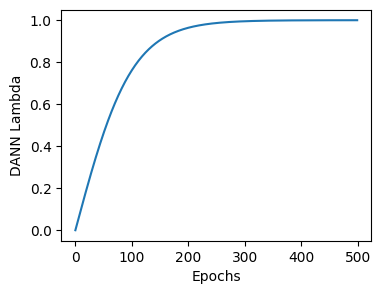

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.plot(lambds)
ax.set_xlabel('Epochs')
ax.set_ylabel('DANN Lambda')
plt.savefig(r'..\figures\dann\dann_lambda_plot.png', dpi=300)
plt.show()

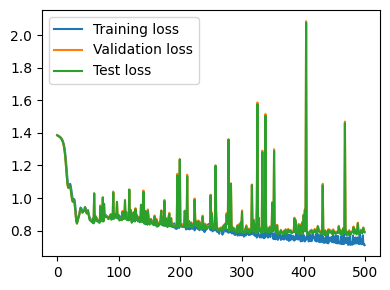

In [23]:
fig, ax = plt.subplots(1,1, figsize=(4,3))
ax.plot(train_losses, label='Training loss')
ax.plot(val_losses, label='Validation loss')
ax.plot(test_losses, label='Test loss')
ax.legend()
plt.tight_layout()
plt.savefig(r'..\figures\dann\combined_loss_normalized_data_weighted_dynamic_lambda.png')

In [24]:
torch.save(model, r'..\results\dann\common_genes\model_normalized_data_weighted_dynamic_lambda.pth')

# evaluation

In [42]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from matplotlib import rc_context

In [43]:
model.eval()
true_labels = []
pred_labels = []
true_batch = []
pred_batch = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        label_out, batch_out = model(data.x, data.edge_index, data.batch)
        _, pred = torch.max(label_out, dim=1)
        _, batch = torch.max(batch_out, dim=1)
        true_labels.extend(data.label.cpu().numpy())
        pred_labels.extend(pred.cpu().numpy())
        true_batch.extend(data.source_label.cpu().numpy())
        pred_batch.extend(batch.cpu().numpy())
    
cm_label = confusion_matrix(true_labels, pred_labels)
cm_batch = confusion_matrix(true_batch, pred_batch)

In [44]:
cm_label

array([[2383,  109],
       [ 228, 5944]])

In [45]:
cm_batch

array([[5291, 1462],
       [1242,  669]])

In [46]:
pred_probs = []
batch_probs = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        pred_out, batch_out = model(data.x, data.edge_index, data.batch)
        pred_probs.extend(pred_out.cpu().numpy()[:,1])
        batch_probs.extend(batch_out.cpu().numpy()[:,1])

auc = roc_auc_score(true_labels, pred_probs)
auc_batch = roc_auc_score(true_batch, batch_probs)

roc_curve_pred = roc_curve(true_labels, pred_probs)
roc_curve_batch = roc_curve(true_batch, batch_probs)

(array([  2.,   3.,   9.,  22.,  22.,  55.,  79., 156., 206., 286., 302.,
        255., 260., 230., 199., 116.,  78.,  69.,  54.,  43.,  52.,  53.,
         60.,  79.,  83.,  94.,  81., 117., 127., 136., 157., 190., 194.,
        233., 351., 510., 582., 611., 636., 578., 483., 325., 222., 132.,
         69.,  36.,  16.,   6.,   3.,   2.]),
 array([-5.34259319, -5.11278439, -4.88297558, -4.65316629, -4.42335749,
        -4.19354868, -3.96373963, -3.73393059, -3.50412178, -3.27431297,
        -3.04450393, -2.81469488, -2.58488607, -2.35507727, -2.12526822,
        -1.89545918, -1.66565037, -1.43584156, -1.20603275, -0.97622347,
        -0.74641466, -0.51660585, -0.28679657, -0.05698776,  0.17282104,
         0.40262985,  0.63243866,  0.86224794,  1.09205675,  1.32186556,
         1.55167484,  1.78148365,  2.01129246,  2.24110126,  2.47091007,
         2.70071888,  2.93052769,  3.16033745,  3.39014626,  3.61995506,
         3.84976387,  4.07957268,  4.30938148,  4.53919029,  4.76900005,
 

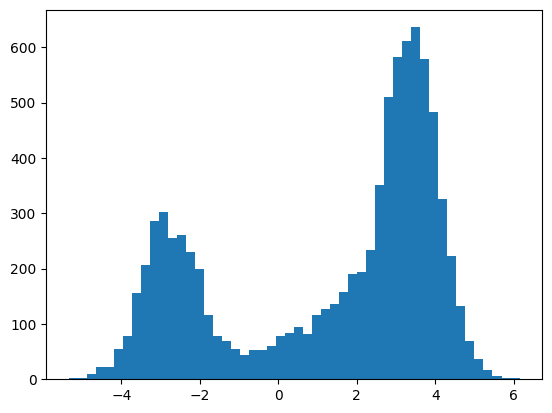

In [ ]:
plt.hist(pred_probs,bins=50,)

(array([1.000e+00, 1.000e+00, 2.000e+00, 1.000e+00, 1.200e+01, 4.400e+01,
        8.500e+01, 1.740e+02, 2.100e+02, 2.390e+02, 2.720e+02, 2.640e+02,
        2.020e+02, 1.690e+02, 1.220e+02, 1.030e+02, 1.070e+02, 8.600e+01,
        6.300e+01, 5.400e+01, 4.100e+01, 6.300e+01, 6.400e+01, 5.400e+01,
        5.000e+01, 6.700e+01, 6.500e+01, 7.200e+01, 1.130e+02, 2.730e+02,
        5.930e+02, 1.068e+03, 1.163e+03, 1.011e+03, 7.230e+02, 4.360e+02,
        2.280e+02, 1.480e+02, 7.800e+01, 5.700e+01, 3.100e+01, 2.000e+01,
        1.600e+01, 7.000e+00, 5.000e+00, 4.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 2.000e+00]),
 array([-0.70656258, -0.68092537, -0.65528822, -0.62965101, -0.6040138 ,
        -0.57837659, -0.55273938, -0.52710223, -0.50146502, -0.47582781,
        -0.45019063, -0.42455345, -0.39891624, -0.37327904, -0.34764186,
        -0.32200468, -0.29636747, -0.27073026, -0.24509308, -0.2194559 ,
        -0.19381869, -0.16818148, -0.14254433, -0.11690712, -0.09126991,
        -0.

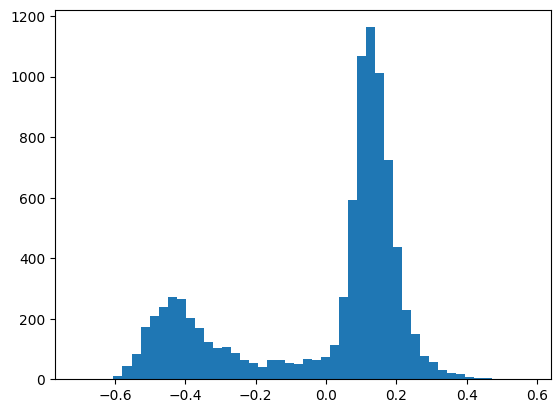

In [64]:
plt.hist(batch_probs,bins=50)

In [47]:
auc

np.float64(0.501742159485857)

In [48]:
auc_batch

np.float64(0.48176099883277645)

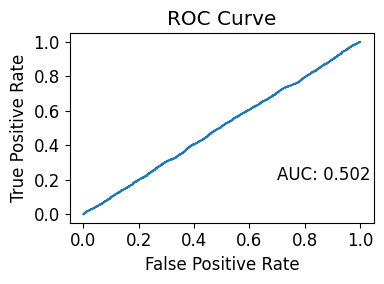

In [49]:
with rc_context({'font.size':12}):
    fig, ax = plt.subplots(1,1,figsize=(4,3))
    ax.plot(roc_curve_pred[0], roc_curve_pred[1])
    ax.text(0.7, 0.2, f'AUC: {auc:.3f}', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve')
    plt.tight_layout()
    plt.savefig(r'..\figures\dann\roc_curve_pred_normalized_data_weighted_dynamic_lambda.png')

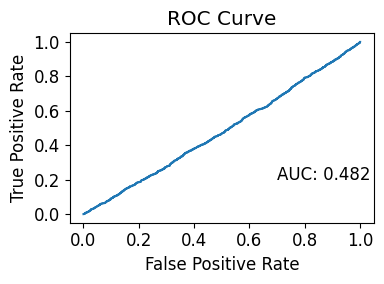

In [50]:
with rc_context({'font.size':12}):
    fig, ax = plt.subplots(1,1,figsize=(4,3))
    ax.plot(roc_curve_batch[0], roc_curve_batch[1])
    ax.text(0.7, 0.2, f'AUC: {auc_batch:.3f}', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve')
    plt.tight_layout()
    plt.savefig(r'..\figures\dann\roc_curve_batch_normalized_data_weighted_dynamic_lambda.png')

# Embedding

In [51]:
model.eval()
pooled_features = []

data = xenium_data_83a + xenium_data_83b + xenium_data_84a + xenium_data_84b +\
       xenium_data_174c + xenium_data_174d + xenium_data_7202c + xenium_data_7202d +\
       merfish_data_7289 + merfish_data_7295 + merfish_data_7320 + merfish_data_159 + merfish_data_163
data_loader = DataLoader(data, batch_size=256, shuffle=False)

with torch.no_grad():
    for data in data_loader:
        data = data.to(device)
        out = model.encoder(data.x, data.edge_index)
        out1 = pool.global_mean_pool(out, data.batch)
        out2 = pool.global_max_pool(out, data.batch)
        out = torch.cat([out1, out2], dim=1)

        pooled_features.append(out.cpu().numpy())

c:\Users\zfang38\AppData\Local\anaconda3\envs\torchEnv\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [57]:
with open(r'..\results\dann\common_genes\pooled_features_normalized_data_weighted_dynamic_lambda.pkl', 'wb') as f:
    pickle.dump(pooled_features, f)

In [53]:
slices = ['Xenium_83a']*len(xenium_data_83a) + ['Xenium_83b']*len(xenium_data_83b) +\
         ['Xenium_84a']*len(xenium_data_84a) + ['Xenium_84b']*len(xenium_data_84b) +\
         ['Xenium_174c']*len(xenium_data_174c) + ['Xenium_174d']*len(xenium_data_174d) +\
         ['Xenium_7202c']*len(xenium_data_7202c) + ['Xenium_7202d']*len(xenium_data_7202d) +\
         ['MERFISH_7289']*len(merfish_data_7289) + ['MERFISH_7295']*len(merfish_data_7295) +\
         ['MERFISH_7320']*len(merfish_data_7320) + ['MERFISH_159']*len(merfish_data_159) +\
         ['MERFISH_163']*len(merfish_data_163)

In [56]:
with open(r'..\results\dann\common_genes\tissue_id.pkl', 'wb') as f:
    pickle.dump(slices, f)

In [55]:
labels = ['SSA+']*(len(xenium_data_83a)+len(xenium_data_83b)+len(xenium_data_84a)+len(xenium_data_84b)) +\
         ['SSA-']*(len(xenium_data_174c)+len(xenium_data_174d)+len(xenium_data_7202c)+len(xenium_data_7202d)) +\
         ['SSA+']*(len(merfish_data_7289)+len(merfish_data_7295)+len(merfish_data_7320)) +\
         ['SSA-']*(len(merfish_data_159)+len(merfish_data_163))

In [58]:
with open(r'..\results\dann\common_genes\pooled_labls.pkl', 'wb') as f:
    pickle.dump(labels, f)

In [59]:
experiments = ['Xenium']*(len(xenium_data_83a)+len(xenium_data_83b)+\
                          len(xenium_data_84a)+len(xenium_data_84b)+\
                          len(xenium_data_174c)+len(xenium_data_174d)+\
                          len(xenium_data_7202c)+len(xenium_data_7202d))+\
              ['MERFISH']*(len(merfish_data_7289)+len(merfish_data_7295)+\
                           len(merfish_data_7320)+len(merfish_data_159)+\
                           len(merfish_data_163))

In [60]:
with open(r'..\results\dann\common_genes\pooled_experiments.pkl', 'wb') as f:
    pickle.dump(experiments, f)